# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder /data
 
  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

In [1]:
# import packages,...

# set random_state = 0
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Tìm hiểu dữ liệu

In [10]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Chú ý:
    - Đọc mô tả dữ liệu trong file 'australian.doc'
    - Kiểm tra DecisionTree/RandomForest của Sklearn có hỗ trợ với kiểu dữ liệu được cung cấp không
'''
data_path = 'australian.dat'
df=pd.read_csv(data_path,sep=' ',header=None)
df.info()
df.isnull().sum()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    int64  
 1   1       690 non-null    float64
 2   2       690 non-null    float64
 3   3       690 non-null    int64  
 4   4       690 non-null    int64  
 5   5       690 non-null    int64  
 6   6       690 non-null    float64
 7   7       690 non-null    int64  
 8   8       690 non-null    int64  
 9   9       690 non-null    int64  
 10  10      690 non-null    int64  
 11  11      690 non-null    int64  
 12  12      690 non-null    int64  
 13  13      690 non-null    int64  
 14  14      690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
5,0,15.83,0.585,2,8,8,1.500,1,1,2,0,2,100,1,1
6,1,17.42,6.500,2,3,4,0.125,0,0,0,0,2,60,101,0
7,0,58.67,4.460,2,11,8,3.040,1,1,6,0,2,43,561,1
8,1,27.83,1.000,1,2,8,3.000,0,0,0,0,2,176,538,0
9,0,55.75,7.080,2,4,8,6.750,1,1,3,1,2,100,51,0


In [ ]:
#Xử lý và phân chia dữ liệu
from sklearn.model_selection import train_test_split
y=df[14]
X=df.drop(14,axis=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213
1,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1
2,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1
3,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1
4,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159
5,0,15.83,0.585,2,8,8,1.500,1,1,2,0,2,100,1
6,1,17.42,6.500,2,3,4,0.125,0,0,0,0,2,60,101
7,0,58.67,4.460,2,11,8,3.040,1,1,6,0,2,43,561
8,1,27.83,1.000,1,2,8,3.000,0,0,0,0,2,176,538
9,0,55.75,7.080,2,4,8,6.750,1,1,3,1,2,100,51


## 2. Decision Tree

### 2.1. Khảo sát các giá trị khác nhau của max_depth

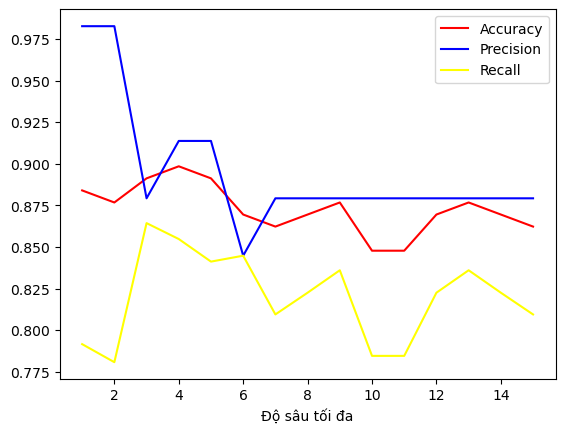

In [ ]:
# code
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score
depths=range(1,16)
acc,pre,rec=[],[],[]
for depth in depths:
    model=DecisionTreeClassifier(criterion='gini',max_depth=depth,min_samples_leaf=5)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc.append(accuracy_score(y_pred,y_test))
    pre.append(precision_score(y_pred,y_test))
    rec.append(recall_score(y_pred,y_test))

plt.plot(depths,acc,color='red',label="Accuracy")
plt.plot(depths,pre,color='blue',label="Precision")
plt.plot(depths,rec,color='yellow',label="Recall")

plt.xlabel("Độ sâu tối đa")

plt.legend()
plt.show()

### 2.2. Tìm kiếm siêu tham số

In [44]:
#code
from sklearn.model_selection import GridSearchCV#Giúp chia k-fold để tìm ra bộ tham số tốt nhất
model=DecisionTreeClassifier()
param= {
    'max_depth':range(1,11),
    'min_samples_split': range(5,20),
    'min_samples_leaf': range(5,11)
}

grid_search = GridSearchCV(estimator=model, param_grid=param,cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
print("Bộ siêu tham số tốt nhất :", grid_search.best_params_)
y_pred=grid_search.predict(X_test)
print(f"Accuracy : {accuracy_score(y_pred,y_test)}")
print(f"Precision : {precision_score(y_pred,y_test)}")
print(f"Recall : {recall_score(y_pred,y_test)}")


Bộ siêu tham số tốt nhất : {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 17}
Accuracy : 0.8623188405797102
Precision : 0.8103448275862069
Recall : 0.8545454545454545


## 3. Random Forest

### 3.1 Khảo sát các giá trị khác nhau của n_estimators

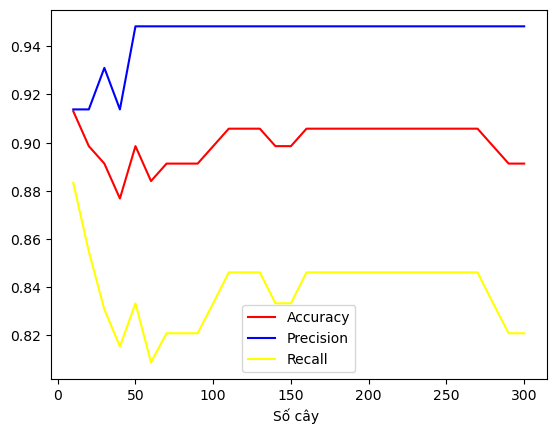

In [50]:
#code
from sklearn.ensemble import RandomForestClassifier
n_estimators=range(10,301,10)
acc,pre,rec=[],[],[]
for n in n_estimators:
    model=RandomForestClassifier(n_estimators=n,random_state=10)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc.append(accuracy_score(y_pred,y_test))
    pre.append(precision_score(y_pred,y_test))
    rec.append(recall_score(y_pred,y_test))

plt.plot(n_estimators,acc,color='red',label="Accuracy")
plt.plot(n_estimators,pre,color='blue',label="Precision")
plt.plot(n_estimators,rec,color='yellow',label="Recall")

plt.xlabel("Số cây ")

plt.legend()
plt.show()

### 3.2 Tìm kiếm siêu tham số

In [53]:
# code
from sklearn.model_selection import GridSearchCV#Giúp chia k-fold để tìm ra bộ tham số tốt nhất
model=RandomForestClassifier()
param= {
    'min_samples_leaf': range(1,11),
    'max_features': [1.0,'log2','sqrt','auto'],
    'n_estimators':range(50,150,20)
}

grid_search = GridSearchCV(estimator=model, param_grid=param,cv=5)
grid_search.fit(X_train, y_train)
print("Bộ siêu tham số tốt nhất :", grid_search.best_params_)
y_pred=grid_search.predict(X_test)
print(f"Accuracy : {accuracy_score(y_pred,y_test)}")
print(f"Precision : {precision_score(y_pred,y_test)}")
print(f"Recall : {recall_score(y_pred,y_test)}")

Bộ siêu tham số tốt nhất : {'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 90}
Accuracy : 0.9057971014492754
Precision : 0.9482758620689655
Recall : 0.8461538461538461


c:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
250 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
250 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate